# 🛍️ Customer Segmentation Analysis

## Objective

Apply clustering algorithms to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

### Tech Stack

Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, Jupyter Notebook

In [9]:
# 1. Import Required Libraries


# Import Pandas for data manipulation
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib for visualization
import matplotlib.pyplot as plt

# Import Seaborn for advanced visualizations
import seaborn as sns

# Import StandardScaler for feature standardization
from sklearn.preprocessing import StandardScaler

# Import KMeans clustering algorithm
from sklearn.cluster import KMeans

In [13]:
# 2. Load Dataset


# Load the e-commerce sales dataset
df = pd.read_csv("global_ecommerce_sales.csv")

# Display the first 5 rows
df.head()

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


In [14]:
# 3. Inspect Dataset Structure


# Check the number of rows and columns
print("Dataset Shape:", df.shape)

# Display all column names
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (2000, 15)

Column Names:
['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment', 'Country', 'Region', 'Product_Category', 'Product_Name', 'Quantity', 'Unit_Price', 'Discount_Percent', 'Total_Sales', 'Shipping_Cost', 'Profit', 'Payment_Method']


In [15]:
# 4. Check Data Types


# Display information about columns, data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   object 
 1   Order_Date        2000 non-null   object 
 2   Customer_Name     2000 non-null   object 
 3   Customer_Segment  2000 non-null   object 
 4   Country           2000 non-null   object 
 5   Region            2000 non-null   object 
 6   Product_Category  2000 non-null   object 
 7   Product_Name      2000 non-null   object 
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   object 
dtypes: float64(4), int64(2), object(9)
memory usage: 234.5+ KB


In [16]:
# 5. Check Missing Values

# Count missing values in every column
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Country             0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Total_Sales         0
Shipping_Cost       0
Profit              0
Payment_Method      0
dtype: int64


In [17]:
# 6. Calculate Missing Value Percentage


# Calculate percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Value Percentage:")
print(missing_percentage)

Missing Value Percentage:
Order_ID            0.0
Order_Date          0.0
Customer_Name       0.0
Customer_Segment    0.0
Country             0.0
Region              0.0
Product_Category    0.0
Product_Name        0.0
Quantity            0.0
Unit_Price          0.0
Discount_Percent    0.0
Total_Sales         0.0
Shipping_Cost       0.0
Profit              0.0
Payment_Method      0.0
dtype: float64


In [18]:
# 7. Check Duplicate Records


# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [19]:
# 8. Remove Duplicate Records
# Remove duplicate rows
df = df.drop_duplicates().copy()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (2000, 15)


In [20]:
# 9. Convert Order Date

# Convert Order_Date from object/string to datetime
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

# Check the result
print(df["Order_Date"].dtype)

datetime64[ns]


In [21]:
# 10. Check Invalid Dates

# Count invalid or missing dates after conversion
invalid_dates = df["Order_Date"].isnull().sum()

print("Invalid Order Dates:", invalid_dates)

Invalid Order Dates: 0


In [22]:
# 11. Handle Missing Values

# Display columns containing missing values
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [23]:
# Fill numerical missing values with median
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

# Fill categorical missing values with "Unknown"
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna("Unknown")

# Check missing values again
print(df.isnull().sum())

Order_ID            0
Order_Date          0
Customer_Name       0
Customer_Segment    0
Country             0
Region              0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount_Percent    0
Total_Sales         0
Shipping_Cost       0
Profit              0
Payment_Method      0
dtype: int64


In [24]:
# 12. Check Inconsistent Customer Names


# Remove unnecessary spaces from customer names
df["Customer_Name"] = df["Customer_Name"].astype(str).str.strip()

# Display number of unique customers
print("Unique Customers:", df["Customer_Name"].nunique())

Unique Customers: 1534


In [25]:
# 13. Check Numerical Data

# Display descriptive statistics for numerical columns
df.describe()

,Order_Date,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit
count,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,2024-07-12 03:17:16.800000,3.557500,73.329490,8.572500,242.279670,12.90212,79.436160
min,2023-01-02 00:00:00,1.000000,3.030000,0.000000,2.420000,5.52000,-11.280000
25%,2023-10-08 00:00:00,2.000000,18.757500,0.000000,41.227500,9.45750,6.865000
50%,2024-07-12 12:00:00,3.000000,46.420000,10.000000,113.125000,11.84500,32.830000
75%,2025-04-20 06:00:00,5.000000,90.250000,15.000000,266.552500,14.92000,90.297500
max,2025-12-31 00:00:00,15.000000,472.560000,30.000000,3813.980000,40.44000,1373.630000
std,NaN,2.704506,79.311014,7.261274,382.583802,5.22319,137.573593


In [26]:
# 14. Check Negative or Zero Sales

# Check invalid Total_Sales values
print("Sales <= 0:", (df["Total_Sales"] <= 0).sum())

# Check invalid Quantity values
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())

# Check invalid Unit Price values
print("Unit Price <= 0:", (df["Unit_Price"] <= 0).sum())

Sales <= 0: 0
Quantity <= 0: 0
Unit Price <= 0: 0


In [27]:
# 15. Basic Data Validation

# Check the minimum and maximum values
print("Minimum Sales:", df["Total_Sales"].min())
print("Maximum Sales:", df["Total_Sales"].max())

print("Minimum Quantity:", df["Quantity"].min())
print("Maximum Quantity:", df["Quantity"].max())

print("Minimum Unit Price:", df["Unit_Price"].min())
print("Maximum Unit Price:", df["Unit_Price"].max())

Minimum Sales: 2.42
Maximum Sales: 3813.98
Minimum Quantity: 1
Maximum Quantity: 15
Minimum Unit Price: 3.03
Maximum Unit Price: 472.56


In [28]:
# 16. Descriptive Statistics

# Calculate important descriptive statistics
descriptive_statistics = df[
    ["Quantity", "Unit_Price", "Total_Sales", "Shipping_Cost", "Profit"]
].describe()

descriptive_statistics

,Quantity,Unit_Price,Total_Sales,Shipping_Cost,Profit
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,3.557500,73.329490,242.279670,12.90212,79.436160
std,2.704506,79.311014,382.583802,5.22319,137.573593
min,1.000000,3.030000,2.420000,5.52000,-11.280000
25%,2.000000,18.757500,41.227500,9.45750,6.865000
50%,3.000000,46.420000,113.125000,11.84500,32.830000
75%,5.000000,90.250000,266.552500,14.92000,90.297500
max,15.000000,472.560000,3813.980000,40.44000,1373.630000


In [29]:
# 17. Calculate Average Purchase Value


# Calculate average purchase value per order
average_purchase_value = df["Total_Sales"].mean()

print(
    "Average Purchase Value:",
    round(average_purchase_value, 2)
)

Average Purchase Value: 242.28


In [30]:
# 18. Calculate Purchase Frequency


# Calculate number of unique orders made by each customer
purchase_frequency = (
    df.groupby("Customer_Name")["Order_ID"]
    .nunique()
)

print("Average Purchase Frequency:",
      round(purchase_frequency.mean(), 2))

purchase_frequency.head()

Average Purchase Frequency: 1.3


Customer_Name
Ahmed Ali         1
Ahmed Anderson    1
Ahmed Clark       2
Ahmed Dubois      3
Ahmed Garcia      2
Name: Order_ID, dtype: int64

In [31]:
# 19. Calculate Customer Lifetime Value

# Calculate total sales generated by each customer
customer_lifetime_value = (
    df.groupby("Customer_Name")["Total_Sales"]
    .sum()
)

print("Average Customer Lifetime Value:",
      round(customer_lifetime_value.mean(), 2))

customer_lifetime_value.head()

Average Customer Lifetime Value: 315.88


Customer_Name
Ahmed Ali          509.12
Ahmed Anderson     133.68
Ahmed Clark         94.28
Ahmed Dubois       105.73
Ahmed Garcia      1769.48
Name: Total_Sales, dtype: float64

In [32]:
# 20. Calculate Customer-Level Total Quantity

# Calculate total quantity purchased by each customer
customer_quantity = (
    df.groupby("Customer_Name")["Quantity"]
    .sum()
)

customer_quantity.head()

Customer_Name
Ahmed Ali         12
Ahmed Anderson     4
Ahmed Clark        4
Ahmed Dubois       3
Ahmed Garcia      14
Name: Quantity, dtype: int64

In [33]:
# 21. Set Reference Date for RFM

# Use the day after the latest order as the reference date
reference_date = df["Order_Date"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2026-01-01 00:00:00


In [34]:
# 22. Calculate Recency

# Calculate the latest purchase date for every customer
last_purchase = (
    df.groupby("Customer_Name")["Order_Date"]
    .max()
)

# Calculate number of days since the last purchase
recency = (
    reference_date - last_purchase
).dt.days

recency.head()

Customer_Name
Ahmed Ali         384
Ahmed Anderson    494
Ahmed Clark       636
Ahmed Dubois       23
Ahmed Garcia      923
Name: Order_Date, dtype: int64

In [35]:
# 23. Calculate Frequency

# Calculate number of unique orders made by each customer
frequency = (
    df.groupby("Customer_Name")["Order_ID"]
    .nunique()
)

frequency.head()

Customer_Name
Ahmed Ali         1
Ahmed Anderson    1
Ahmed Clark       2
Ahmed Dubois      3
Ahmed Garcia      2
Name: Order_ID, dtype: int64

In [36]:
# 24. Calculate Monetary Value

# Calculate total money spent by each customer
monetary = (
    df.groupby("Customer_Name")["Total_Sales"]
    .sum()
)

monetary.head()

Customer_Name
Ahmed Ali          509.12
Ahmed Anderson     133.68
Ahmed Clark         94.28
Ahmed Dubois       105.73
Ahmed Garcia      1769.48
Name: Total_Sales, dtype: float64

In [37]:
# 25. Create RFM Dataset

# Combine Recency, Frequency and Monetary values
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

# Display RFM dataset
rfm.head()

,Recency,Frequency,Monetary
Customer_Name,,,
Ahmed Ali,384,1,509.12
Ahmed Anderson,494,1,133.68
Ahmed Clark,636,2,94.28
Ahmed Dubois,23,3,105.73
Ahmed Garcia,923,2,1769.48


In [38]:
# 26. Check RFM Dataset

# Check RFM shape
print("RFM Shape:", rfm.shape)

# Check missing values
print("\nMissing Values:")
print(rfm.isnull().sum())

# Display statistics
rfm.describe()

RFM Shape: (1534, 3)

Missing Values:
Recency      0
Frequency    0
Monetary     0
dtype: int64


,Recency,Frequency,Monetary
count,1534.000000,1534.000000,1534.000000
mean,482.233377,1.303781,315.879622
std,314.331858,0.566767,453.225204
min,1.000000,1.000000,2.580000
25%,210.000000,1.000000,57.055000
50%,449.000000,1.000000,151.430000
75%,752.000000,2.000000,391.900000
max,1095.000000,5.000000,3836.460000


In [41]:
# 27. Select Behavioural Features

# Select the three key customer behaviour features
rfm_features = rfm[
    ["Recency", "Frequency", "Monetary"]
].copy()

rfm_features.head()




,Recency,Frequency,Monetary
Customer_Name,,,
Ahmed Ali,384,1,509.12
Ahmed Anderson,494,1,133.68
Ahmed Clark,636,2,94.28
Ahmed Dubois,23,3,105.73
Ahmed Garcia,923,2,1769.48


### Selected Features

* **Recency** → How recently the customer purchased.
* **Frequency** → How often the customer purchases.
* **Monetary** → How much money the customer spends.

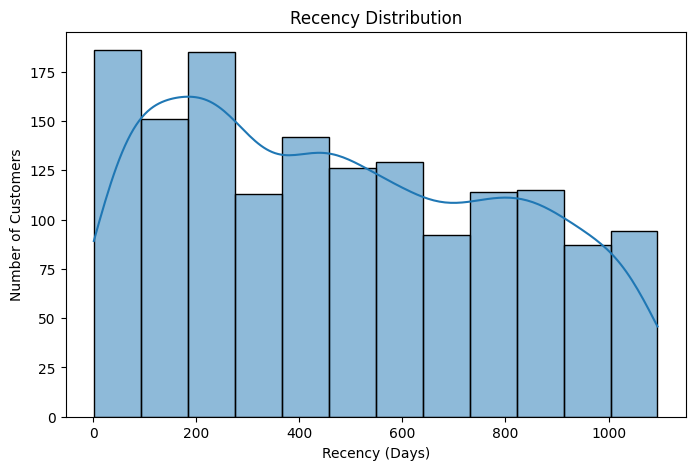

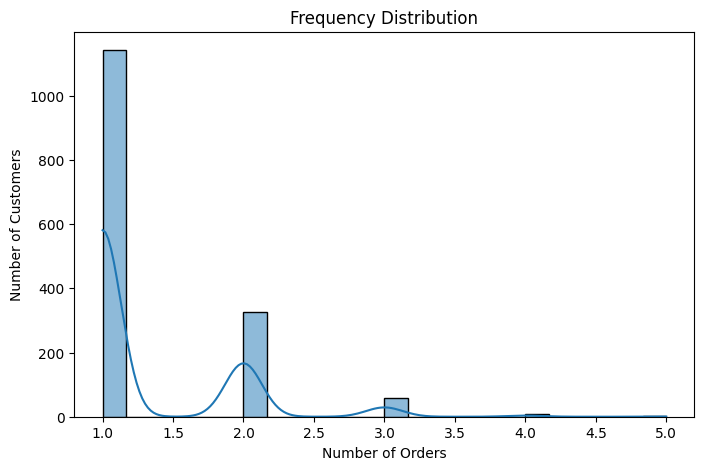

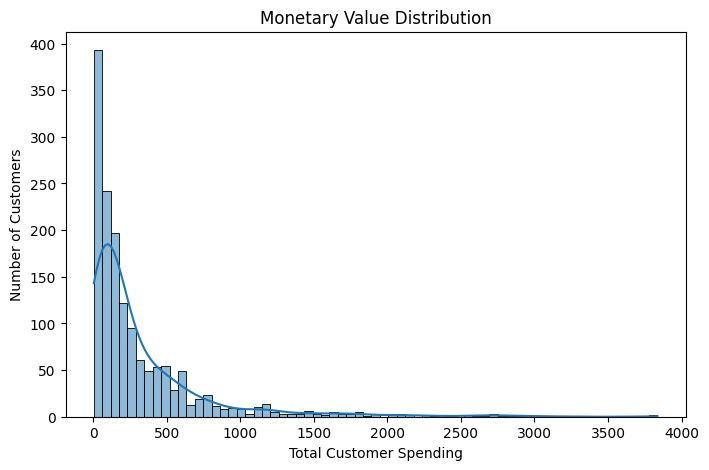

In [43]:
# 28. Visualize RFM Distributions


# Plot distribution of Recency
plt.figure(figsize=(8, 5))
sns.histplot(rfm["Recency"], kde=True)
plt.title("Recency Distribution")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")
plt.show()



# Plot distribution of Frequency
plt.figure(figsize=(8, 5))
sns.histplot(rfm["Frequency"], kde=True)
plt.title("Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()



# Plot distribution of Monetary
plt.figure(figsize=(8, 5))
sns.histplot(rfm["Monetary"], kde=True)
plt.title("Monetary Value Distribution")
plt.xlabel("Total Customer Spending")
plt.ylabel("Number of Customers")
plt.show()

In [44]:
# 29. Standardize RFM Features


# Create StandardScaler object
scaler = StandardScaler()

# Standardize Recency, Frequency and Monetary values
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert standardized data into DataFrame
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
Customer_Name,,,
Ahmed Ali,-0.312617,-0.536164,0.426506
Ahmed Anderson,0.037446,-0.536164,-0.402138
Ahmed Clark,0.489345,1.228804,-0.489099
Ahmed Dubois,-1.461459,2.993773,-0.463827
Ahmed Garcia,1.402691,1.228804,3.208282


In [45]:
# 30. Check Standardized Features


# Check mean and standard deviation after standardization
print("Mean:")
print(rfm_scaled_df.mean())

print("\nStandard Deviation:")
print(rfm_scaled_df.std())

Mean:
Recency     -4.168764e-17
Frequency   -2.315980e-17
Monetary    -3.010774e-17
dtype: float64

Standard Deviation:
Recency      1.000326
Frequency    1.000326
Monetary     1.000326
dtype: float64


In [46]:
# 31. Elbow Method

# Store inertia values for different K values
inertia = []

# Test K values from 2 to 10
for k in range(2, 11):

    # Create K-Means model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Train model
    kmeans.fit(rfm_scaled_df)

    # Store inertia
    inertia.append(kmeans.inertia_)

print("Inertia Values:")
print(inertia)

Inertia Values:
[3050.337751528259, 2164.36836972914, 1440.2300715485371, 1223.8681073070497, 1063.3901204743797, 921.1758841096454, 787.0927998733864, 700.7235741628048, 621.0668694581203]


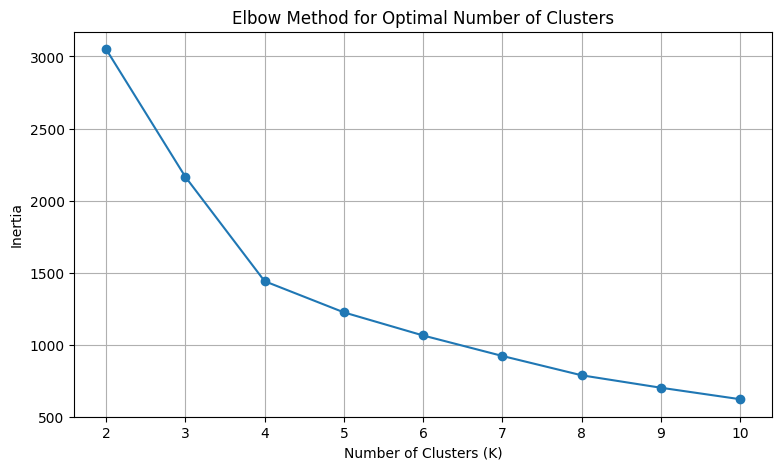

In [47]:
# 32. Plot Elbow Curve

# Plot the Elbow Method
plt.figure(figsize=(9, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [48]:
# 33. Select Optimal K


# Set the optimal number of clusters based on the elbow plot
# Change this value if your elbow plot indicates another K
optimal_k = 4

print("Selected Number of Clusters:", optimal_k)

Selected Number of Clusters: 4


In [49]:
# 34. Apply K-Means Clustering


# Create final K-Means model
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Fit the model and assign cluster labels
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled_df)

# Display customer clusters
rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer_Name,,,,
Ahmed Ali,384,1,509.12,0
Ahmed Anderson,494,1,133.68,0
Ahmed Clark,636,2,94.28,2
Ahmed Dubois,23,3,105.73,2
Ahmed Garcia,923,2,1769.48,3


In [50]:
# 35. Count Customers in Each Cluster

# Count customers in every cluster
cluster_counts = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

print("Customers per Cluster:")
print(cluster_counts)

Customers per Cluster:
Cluster
0    570
1    545
2    341
3     78
Name: count, dtype: int64


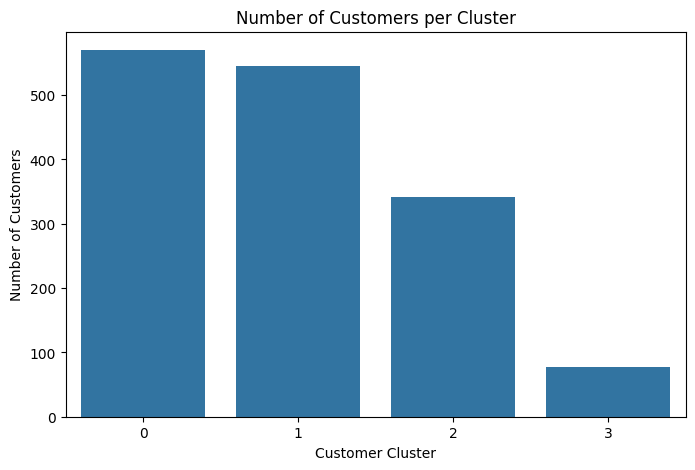

In [51]:
# 36. Bar Chart — Customers per Cluster

# Plot number of customers in each cluster
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.show()

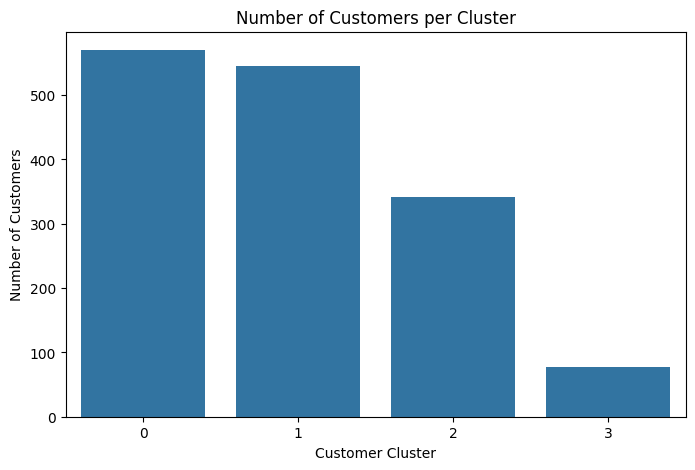

In [52]:
# 36. Bar Chart — Customers per Cluster


# Plot number of customers in each cluster
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.show()

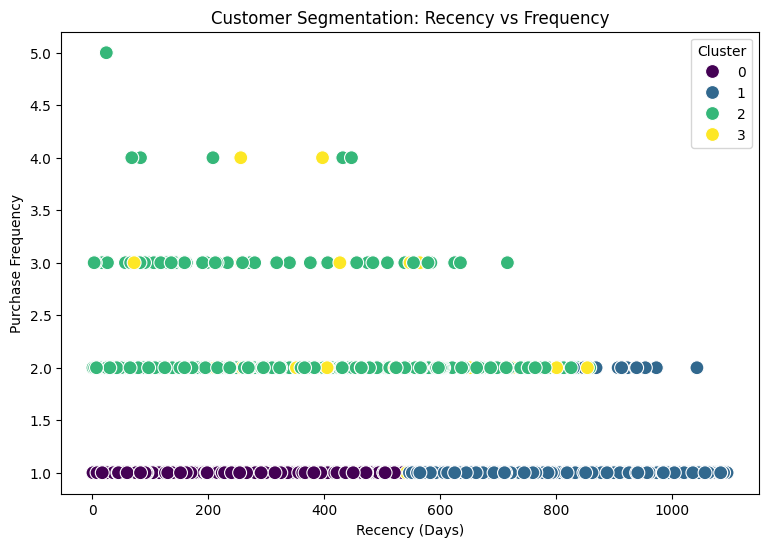

In [53]:
# 37. Scatter Plot — Recency vs Frequency

# Visualize customer clusters using Recency and Frequency
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="viridis",
    s=100
)

plt.title("Customer Segmentation: Recency vs Frequency")
plt.xlabel("Recency (Days)")
plt.ylabel("Purchase Frequency")
plt.legend(title="Cluster")

plt.show()

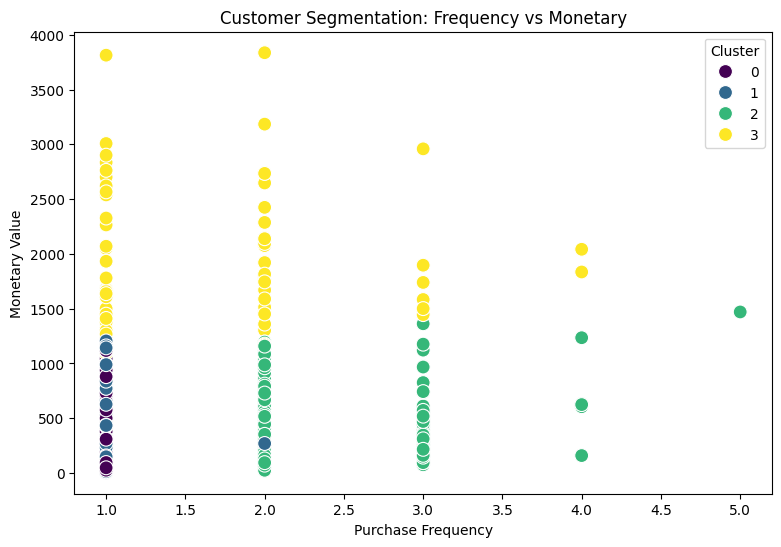

In [54]:
# 38. Scatter Plot — Frequency vs Monetary

# Visualize customer clusters using Frequency and Monetary Value
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=100
)

plt.title("Customer Segmentation: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.legend(title="Cluster")

plt.show()

In [56]:
# 39. Cluster Profiling and Marketing Recommendations


# Calculate average RFM values for every cluster
cluster_profile = (
    rfm.groupby("Cluster")[
        ["Recency", "Frequency", "Monetary"]
    ]
    .mean()
    .round(2)
)

print("Cluster Profile:")

# Add customer count to the cluster profile
cluster_profile["Customer_Count"] = (
    rfm.groupby("Cluster").size()
)


# Create a function to classify customer types
def classify_customer(row):

    if (
        row["Recency"] <= rfm["Recency"].median()
        and row["Frequency"] >= rfm["Frequency"].median()
        and row["Monetary"] >= rfm["Monetary"].median()
    ):
        return "High-Value Customers"

    elif (
        row["Recency"] <= rfm["Recency"].median()
        and row["Frequency"] >= rfm["Frequency"].median()
    ):
        return "Loyal Customers"

    elif row["Recency"] > rfm["Recency"].median():
        return "At-Risk Customers"

    else:
        return "Low-Value / New Customers"


# Apply classification to each cluster
cluster_profile["Customer_Type"] = (
    cluster_profile.apply(classify_customer, axis=1)
)


# Create marketing recommendations
marketing_actions = {
    "High-Value Customers":
        "Offer VIP rewards, exclusive products, premium services and personalized offers.",

    "Loyal Customers":
        "Use loyalty programs, cross-selling, upselling and repeat-purchase discounts.",

    "At-Risk Customers":
        "Use win-back campaigns, personalized discounts, reminders and limited-time offers.",

    "Low-Value / New Customers":
        "Use welcome offers, product recommendations and engagement campaigns."
}

# Display marketing recommendation for every cluster
for cluster, row in cluster_profile.iterrows():

    customer_type = row["Customer_Type"]

    print(f"\nCluster {cluster}")
    print(f"Customer Type: {customer_type}")
    print(f"Customers: {row['Customer_Count']}")
    print(
        f"Average Recency: {row['Recency']:.2f} days"
    )
    print(
        f"Average Frequency: {row['Frequency']:.2f} orders"
    )
    print(
        f"Average Monetary Value: {row['Monetary']:.2f}"
    )
    print(
        "Marketing Action:",
        marketing_actions[customer_type]
    )

Cluster Profile:

Cluster 0
Customer Type: High-Value Customers
Customers: 570
Average Recency: 266.30 days
Average Frequency: 1.00 orders
Average Monetary Value: 180.99
Marketing Action: Offer VIP rewards, exclusive products, premium services and personalized offers.

Cluster 1
Customer Type: At-Risk Customers
Customers: 545
Average Recency: 822.27 days
Average Frequency: 1.03 orders
Average Monetary Value: 195.70
Marketing Action: Use win-back campaigns, personalized discounts, reminders and limited-time offers.

Cluster 2
Customer Type: High-Value Customers
Customers: 341
Average Recency: 305.21 days
Average Frequency: 2.19 orders
Average Monetary Value: 380.79
Marketing Action: Offer VIP rewards, exclusive products, premium services and personalized offers.

Cluster 3
Customer Type: At-Risk Customers
Customers: 78
Average Recency: 458.21 days
Average Frequency: 1.60 orders
Average Monetary Value: 1857.55
Marketing Action: Use win-back campaigns, personalized discounts, reminders an

In [57]:
# 40. Final Customer Segmentation Summary


# Display the final cluster summary
final_summary = cluster_profile[
    [
        "Customer_Count",
        "Recency",
        "Frequency",
        "Monetary",
        "Customer_Type"
    ]
].copy()


# Print final business insights
print("=" * 70)
print("CUSTOMER SEGMENTATION — BUSINESS INSIGHTS")
print("=" * 70)

for cluster, row in final_summary.iterrows():

    print(f"\nCluster {cluster}: {row['Customer_Type']}")

    print(f"- Customers: {int(row['Customer_Count'])}")
    print(f"- Average Recency: {row['Recency']:.2f} days")
    print(f"- Average Frequency: {row['Frequency']:.2f}")
    print(f"- Average Monetary Value: {row['Monetary']:.2f}")

    print(
        f"- Recommended Action: "
        f"{marketing_actions[row['Customer_Type']]}"
    )


## Optional: Export the Results


# Save customer-level segmentation results
rfm.to_csv(
    "customer_segmentation_results.csv"
)

# Save cluster profile
cluster_profile.to_csv(
    "customer_cluster_profile.csv"
)

print("Customer segmentation results exported successfully.")

CUSTOMER SEGMENTATION — BUSINESS INSIGHTS

Cluster 0: High-Value Customers
- Customers: 570
- Average Recency: 266.30 days
- Average Frequency: 1.00
- Average Monetary Value: 180.99
- Recommended Action: Offer VIP rewards, exclusive products, premium services and personalized offers.

Cluster 1: At-Risk Customers
- Customers: 545
- Average Recency: 822.27 days
- Average Frequency: 1.03
- Average Monetary Value: 195.70
- Recommended Action: Use win-back campaigns, personalized discounts, reminders and limited-time offers.

Cluster 2: High-Value Customers
- Customers: 341
- Average Recency: 305.21 days
- Average Frequency: 2.19
- Average Monetary Value: 380.79
- Recommended Action: Offer VIP rewards, exclusive products, premium services and personalized offers.

Cluster 3: At-Risk Customers
- Customers: 78
- Average Recency: 458.21 days
- Average Frequency: 1.60
- Average Monetary Value: 1857.55
- Recommended Action: Use win-back campaigns, personalized discounts, reminders and limited-t

# 🎯 Conclusion

The Customer Segmentation Analysis successfully grouped e-commerce customers based on their purchasing behaviour using **RFM analysis and K-Means clustering**. The **Recency, Frequency, and Monetary** features were standardized using `StandardScaler`, and the **Elbow Method** was used to determine an appropriate number of clusters.

The resulting customer segments revealed different purchasing patterns, including **high-value, loyal, at-risk, and low-value/new customers**. These segments can help the business create targeted marketing strategies such as VIP rewards, loyalty programs, personalized discounts, and win-back campaigns.

Overall, this analysis converts customer transaction data into **actionable customer segments**, helping the business improve **customer retention, engagement, repeat purchases, and revenue through data-driven marketing decisions**.
